# NCHS - Drug Poisoning Mortality by State

This dataset describes drug poisoning deaths at the U.S. and state level by selected demographic characteristics, and includes age-adjusted death rates for drug poisoning. 1999-2016.

In [1]:
import pandas as pd
import numpy as np
from sodapy import Socrata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import skew

In [2]:
# API Configuration
DATASET_ID = "xbxb-epbu"
DOMAIN = "data.cdc.gov"
APP_TOKEN = "CpwHhA1scJ9x7VNZ3PWM8MRG6"

# Initialize client
client = Socrata(DOMAIN, APP_TOKEN)

# Fetch the data
results = client.get(DATASET_ID, limit=5000)

# Convert to pandas DataFrame
df = pd.DataFrame.from_records(results)

df.head()

,state,year,sex,age_group,race_and_hispanic_origin,deaths,population,crude_death_rate,standard_error_for_crude_rate,lower_confidence_limit_for_crude_rate,upper_confidence_limit_for_crude_rate,age_adjusted_rate,standard_error_for_age_adjusted_rate,lower_confidence_limit_for_age_adjusted_rate,upper_confidence_limit_for_age_adjusted_rate,state_crude_rate_in_range,us_crude_rate,us_age_adjusted_rate,unit
0,Alabama,1999,Both Sexes,All Ages,All Races-All Origins,169,4430143,3.8148,0.29344,3.2396,4.3899,3.8521,0.29657,3.2708,4.4334,1.8–7.1,6.0382,6.0570,"per 100,000 population"
1,Alabama,2000,Both Sexes,All Ages,All Races-All Origins,197,4447100,4.4299,0.31561,3.8112,5.0485,4.4857,0.31985,3.8588,5.1126,1.8–7.1,6.1882,6.1749,"per 100,000 population"
2,Alabama,2001,Both Sexes,All Ages,All Races-All Origins,216,4467634,4.8348,0.32896,4.1900,5.4795,4.8915,0.33329,4.2382,5.5447,1.8–7.1,6.8057,6.7922,"per 100,000 population"
3,Alabama,2002,Both Sexes,All Ages,All Races-All Origins,211,4480089,4.7097,0.32423,4.0742,5.3452,4.7619,0.32868,4.1177,5.4062,1.8–7.1,8.1766,8.1957,"per 100,000 population"
4,Alabama,2003,Both Sexes,All Ages,All Races-All Origins,197,4503491,4.3744,0.31166,3.7635,4.9852,4.4333,0.31701,3.8120,5.0547,1.8–7.1,8.8881,8.8765,"per 100,000 population"


In [3]:
df.to_csv('../../data/NCHS_Mortality_Raw.csv', index=False)

## Data Cleaning & Preprocessing

### Handling Issues/Noise in Data
Missing values (imputation, removal, etc.), duplicates and inconsistencies, outliers and anomalies.

**Missing Values**

The data is missing values for `age_adjusted_rate`, `standard_error_for_age_adjusted_rate`, `lower_confidence_limit_for_age_adjusted_rate`,
`upper_confidence_limit_for_age_adjusted_rate`, and `state_crude_rate_in_range` for rows where `age_group` is not "All Ages". When analyzing age-specific data, we will use the crude death rate instead. For data completeness, we will substitute the crude rate for missing rates with the understanding that the columns for age-adjusted rate are only to be used when looking at All Ages. We will drop the range column because its values are inconsistent and we can recreate as needed.

We will also create a new set of columns for death rate that combines the crude and age-adjusted rates based on age group.

In [4]:
# Drop range column
df.drop('state_crude_rate_in_range', axis=1, inplace=True)

In [5]:
# Combine crude and age-adjusted rates to one column for ease of future analysis
df['death_rate'] = np.where(df.age_group=='All Ages', df.age_adjusted_rate, df.crude_death_rate)
df['standard_error_death_rate'] = np.where(df.age_group=='All Ages', df.standard_error_for_age_adjusted_rate, df.standard_error_for_crude_rate)
df['lower_confidence_death_rate'] = np.where(df.age_group=='All Ages', df.lower_confidence_limit_for_age_adjusted_rate, df.lower_confidence_limit_for_crude_rate)
df['upper_confidence_death_rate'] = np.where(df.age_group=='All Ages', df.upper_confidence_limit_for_age_adjusted_rate, df.upper_confidence_limit_for_crude_rate)

In [6]:
df.columns

Index(['state', 'year', 'sex', 'age_group', 'race_and_hispanic_origin',
       'deaths', 'population', 'crude_death_rate',
       'standard_error_for_crude_rate',
       'lower_confidence_limit_for_crude_rate',
       'upper_confidence_limit_for_crude_rate', 'age_adjusted_rate',
       'standard_error_for_age_adjusted_rate',
       'lower_confidence_limit_for_age_adjusted_rate',
       'upper_confidence_limit_for_age_adjusted_rate', 'us_crude_rate',
       'us_age_adjusted_rate', 'unit', 'death_rate',
       'standard_error_death_rate', 'lower_confidence_death_rate',
       'upper_confidence_death_rate'],
      dtype='object')

**Data Types**

In [7]:
cols = ['year',
       'deaths', 'population', 'crude_death_rate',
       'standard_error_for_crude_rate',
       'lower_confidence_limit_for_crude_rate',
       'upper_confidence_limit_for_crude_rate', 'age_adjusted_rate',
       'standard_error_for_age_adjusted_rate',
       'lower_confidence_limit_for_age_adjusted_rate',
       'upper_confidence_limit_for_age_adjusted_rate', 'us_crude_rate',
       'us_age_adjusted_rate', 'death_rate',
       'standard_error_death_rate', 'lower_confidence_death_rate',
       'upper_confidence_death_rate']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

**Outliers**

After inspection, we keep outliers because the numbers make sense when you look at raw death/population numbers. We will add a log transformation to `death_rate` for future linear models, and a z-score standardization for PCA/clustering.

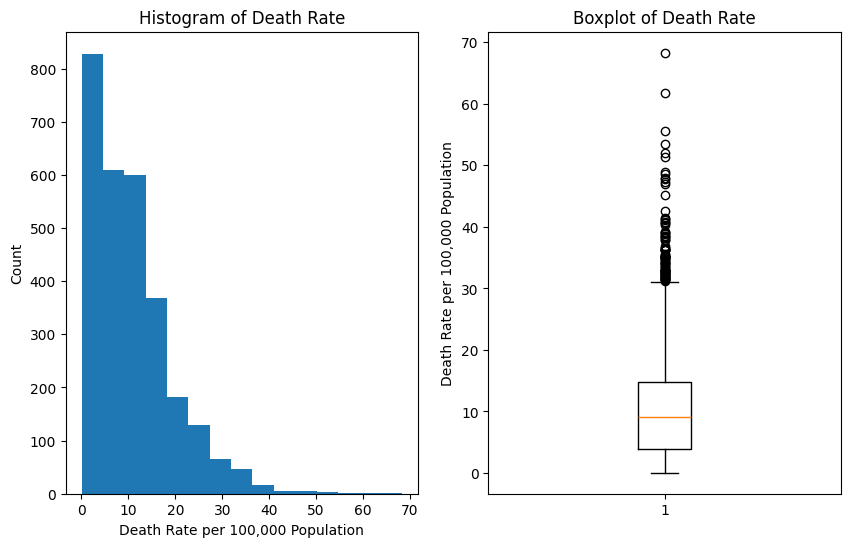

In [8]:
fig, axes = plt.subplots(1,2, figsize=(10,6))
axes[0].hist(df.death_rate, bins=15)
axes[0].set_title('Histogram of Death Rate')
axes[0].set_xlabel('Death Rate per 100,000 Population')
axes[0].set_ylabel('Count')
axes[1].boxplot(df.death_rate)
axes[1].set_title('Boxplot of Death Rate')
axes[1].set_ylabel('Death Rate per 100,000 Population')
plt.show()

In [9]:
# Inspect extreme outliers
df.loc[df.death_rate > 50]

,state,year,sex,age_group,race_and_hispanic_origin,deaths,population,crude_death_rate,standard_error_for_crude_rate,lower_confidence_limit_for_crude_rate,...,standard_error_for_age_adjusted_rate,lower_confidence_limit_for_age_adjusted_rate,upper_confidence_limit_for_age_adjusted_rate,us_crude_rate,us_age_adjusted_rate,unit,death_rate,standard_error_death_rate,lower_confidence_death_rate,upper_confidence_death_rate
2501,United States,2016,Male,45–54,Non-Hispanic Black,1294,2520089,51.3474,1.42742,48.5497,...,NaN,NaN,NaN,19.6925,19.7851,"per 100,000 population",51.3474,1.42742,48.5497,54.1451
2519,United States,2016,Male,55–64,Non-Hispanic Black,1217,2188564,55.6072,1.59399,52.4830,...,NaN,NaN,NaN,19.6925,19.7851,"per 100,000 population",55.6072,1.59399,52.4830,58.7315
2626,United States,2015,Male,25–34,Non-Hispanic White,6874,12848868,53.4989,0.64527,52.2342,...,NaN,NaN,NaN,16.3040,16.2923,"per 100,000 population",53.4989,0.64527,52.2342,54.7636
2627,United States,2016,Male,25–34,Non-Hispanic White,8852,12958146,68.3122,0.72607,66.8891,...,NaN,NaN,NaN,19.6925,19.7851,"per 100,000 population",68.3122,0.72607,66.8891,69.7353
2645,United States,2016,Male,35–44,Non-Hispanic White,7301,11833452,61.6980,0.72207,60.2827,...,NaN,NaN,NaN,19.6925,19.7851,"per 100,000 population",61.6980,0.72207,60.2827,63.1132
2825,West Virginia,2016,Both Sexes,All Ages,All Races-All Origins,884,1831102,48.2769,1.62373,45.0944,...,1.79198,48.5088,55.5334,19.6925,19.7851,"per 100,000 population",52.0211,1.79198,48.5088,55.5334


In [10]:
# Log Transformation
df['death_rate_log'] = np.log10(df.death_rate + 1)

**Race and Hispanic Origin**

Rename categories for brevity.

In [11]:
# Rename column
df.rename(columns={'race_and_hispanic_origin':'race'}, inplace=True)

# Mapping for Race & Hispanic Origin column
race_map = {'All Races-All Origins': 'All Races',
           'Hispanic': 'Hispanic',
           'Non-Hispanic Black':'Black',
           'Non-Hispanic White': 'White'}

df.race = df.race.map(race_map)

**Age Group**

Consolidate into fewer categories

In [12]:
age_map = {'All Ages': 'All Ages',
           '0–14':'0-14',
           '15–24':'15-24',
          '25–34':'25-44',
          '35–44':'25-44',
          '45–54':'45-64',
          '55–64':'45-64',
          '65–74':'65+',
          '75+':'65+'}
df['age_group1'] = df['age_group'].map(age_map)
df.rename(columns={'age_group':'age_group_detail',
                  'age_group1': 'age_group'}, inplace=True)

In [13]:
df.columns

Index(['state', 'year', 'sex', 'age_group_detail', 'race', 'deaths',
       'population', 'crude_death_rate', 'standard_error_for_crude_rate',
       'lower_confidence_limit_for_crude_rate',
       'upper_confidence_limit_for_crude_rate', 'age_adjusted_rate',
       'standard_error_for_age_adjusted_rate',
       'lower_confidence_limit_for_age_adjusted_rate',
       'upper_confidence_limit_for_age_adjusted_rate', 'us_crude_rate',
       'us_age_adjusted_rate', 'unit', 'death_rate',
       'standard_error_death_rate', 'lower_confidence_death_rate',
       'upper_confidence_death_rate', 'death_rate_log', 'age_group'],
      dtype='object')

**Keep Relevant Columns**

In [14]:
cols_to_keep = ['state', 'year', 'sex', 'age_group', 'age_group_detail', 'race',
                'death_rate', 'death_rate_log',
                'us_crude_rate', 'us_age_adjusted_rate',
                'deaths', 'population']

df = df[cols_to_keep]
df.head()

,state,year,sex,age_group,age_group_detail,race,death_rate,death_rate_log,us_crude_rate,us_age_adjusted_rate,deaths,population
0,Alabama,1999,Both Sexes,All Ages,All Ages,All Races,3.8521,0.685930,6.0382,6.0570,169,4430143
1,Alabama,2000,Both Sexes,All Ages,All Ages,All Races,4.4857,0.739232,6.1882,6.1749,197,4447100
2,Alabama,2001,Both Sexes,All Ages,All Ages,All Races,4.8915,0.770226,6.8057,6.7922,216,4467634
3,Alabama,2002,Both Sexes,All Ages,All Ages,All Races,4.7619,0.760566,8.1766,8.1957,211,4480089
4,Alabama,2003,Both Sexes,All Ages,All Ages,All Races,4.4333,0.735064,8.8881,8.8765,197,4503491


**Standardization**

Split into subsets and apply Z-score standardization to `death_rate`.

In [15]:
# Global cumulative level
df_cum = df.loc[(df.state=='United States')&\
                (df.sex=='Both Sexes')&\
                (df.race=='All Races')&\
                (df.age_group=='All Ages')].reset_index(drop=True)



scaler = StandardScaler()

df_cum['death_rate_z_score'] = scaler.fit_transform(df_cum[['death_rate']])

In [16]:
# State cumulative level
df_state = df.loc[(df.state!='United States')&\
                (df.sex=='Both Sexes')&\
                (df.race=='All Races')&\
                (df.age_group=='All Ages')].reset_index(drop=True)

# Initialize
scaler2 = StandardScaler()

df_state['death_rate_z_score'] = scaler2.fit_transform(df_state[['death_rate']])

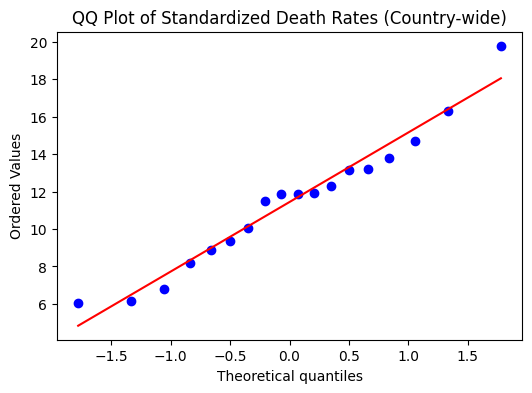

In [17]:
plt.figure(figsize=(6,4))
stats.probplot(df_cum.death_rate, dist='norm', plot=plt)
plt.title('QQ Plot of Standardized Death Rates (Country-wide)')
plt.show()

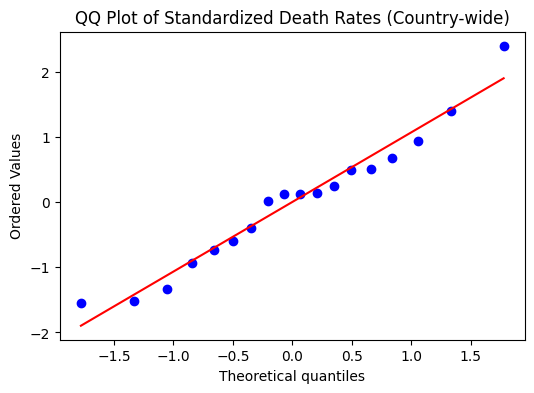

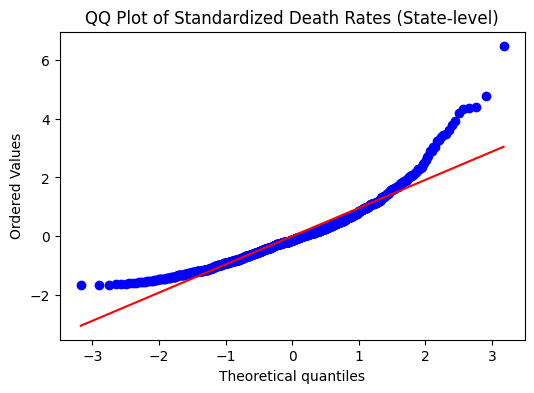

In [18]:
# QQ Plots

plt.figure(figsize=(6,4))
stats.probplot(df_cum.death_rate_z_score, dist='norm', plot=plt)
plt.title('QQ Plot of Standardized Death Rates (Country-wide)')
plt.show()

plt.figure(figsize=(6,4))
stats.probplot(df_state.death_rate_z_score, dist='norm', plot=plt)
plt.title('QQ Plot of Standardized Death Rates (State-level)')
plt.show()

In [19]:
df.describe()

,year,death_rate,death_rate_log,us_crude_rate,us_age_adjusted_rate,deaths,population
count,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000,2.862000e+03
mean,2007.500000,10.710463,0.935112,11.481156,11.440756,1966.582460,1.665024e+07
std,5.189034,8.623297,0.374198,3.487083,3.481560,4806.401872,3.459864e+07
min,1999.000000,0.038900,0.016574,6.038200,6.057000,1.000000,2.381630e+05
25%,2003.000000,3.973800,0.696688,8.888100,8.876500,126.250000,2.730651e+06
50%,2007.500000,9.099300,1.004291,11.970350,11.886100,491.000000,6.423686e+06
75%,2012.000000,14.823000,1.199289,13.267400,13.185200,1526.750000,1.816569e+07
max,2016.000000,68.312200,1.840810,19.692500,19.785100,63632.000000,3.231275e+08


In [20]:
# Skewness - State level
skew_state = skew(df_state.death_rate)
skew_cum = skew(df_cum.death_rate)
print(f"State-Level Skewness in Death Rate: {skew_state:.4f}")
print(f"Cumulative Skewness in Death Rate: {skew_cum:.4f}")

State-Level Skewness in Death Rate: 1.4468
Cumulative Skewness in Death Rate: 0.3803


In [21]:
# Export Clean Data
df.to_csv('../../data/NCHS_Mortality_Clean.csv', index=False)
df_state.to_csv('../../data/NCHS_Mortality_State.csv', index=False)
df_cum.to_csv('../../data/NCHS_Mortality_Cumulative.csv', index=False)

## Visualizations

In [22]:
import matplotlib.ticker as ticker

FileNotFoundError: [Errno 2] No such file or directory: 'resources/data_exploration_plots_NCHS/mortality_1999_2016.jpeg'

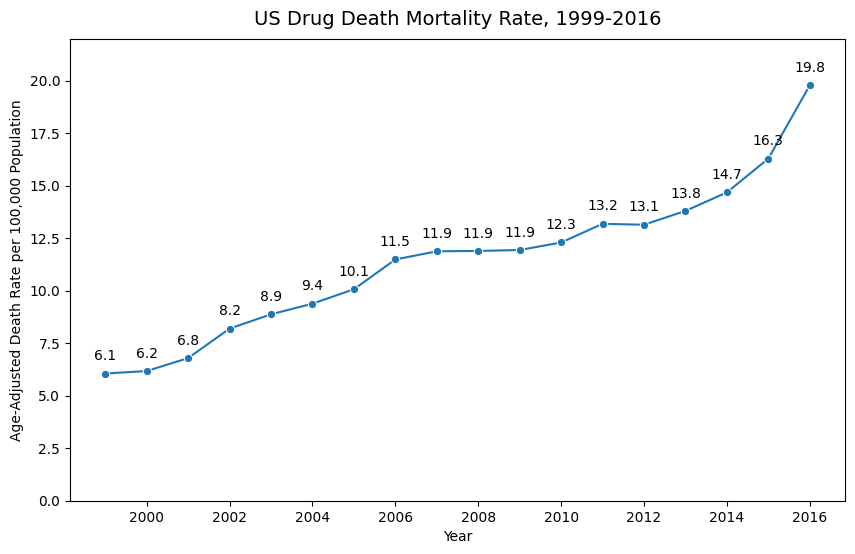

In [23]:
# YoY Change in US Age-Adjusted Death Rate
tmp = df.loc[(df.sex=='Both Sexes')&(df.age_group=='All Ages')&(df.race=='All Races')&\
    (df.state=='United States')].reset_index(drop=True)
tmp = pd.DataFrame(tmp.groupby(['year']).agg({'us_age_adjusted_rate':'mean',
                                                'deaths':'sum'})).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=tmp,
             x='year',
             y='us_age_adjusted_rate',
            marker='o',
            markersize=6)

for i in range(tmp.shape[0]):
    plt.text(tmp.year[i],
             tmp.us_age_adjusted_rate[i] + 0.5,
             f'{tmp.us_age_adjusted_rate[i]:.1f}',
             ha='center', va='bottom',
             fontsize='10')

# sns.barplot(data=tmp,
#             x='year',
#             y='deaths')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.ylim(0,22)
plt.title("US Drug Death Mortality Rate, 1999-2016", fontsize=14, pad=10)
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Death Rate per 100,000 Population')

plt.savefig('resources/data_exploration_plots_NCHS/mortality_1999_2016.jpeg')

plt.show()

In [ ]:
# YoY Change by Race
tmp = df.loc[(df.sex=='Both Sexes')&(df.age_group=='All Ages')&(df.race!='All Races')].reset_index(drop=True)
tmp = pd.DataFrame(tmp.groupby(['year', 'race'])['death_rate'].mean()).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=tmp,
             x='year',
             y='death_rate',
             hue = 'race',
             palette='colorblind',
            marker='o',
            markersize=6)

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Race')
plt.title("US Drug Death Mortality Rate by Race, 1999-2016", fontsize=14, pad=10)
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Death Rate per 100,000 Population')

plt.savefig('resources/data_exploration_plots_NCHS/mortality_race_1999_2016.jpeg')

plt.show()

In [ ]:
# YoY Change by Sex
tmp = df.loc[(df.sex!='Both Sexes')&(df.age_group=='All Ages')&(df.race=='All Races')].reset_index(drop=True)
tmp = pd.DataFrame(tmp.groupby(['year', 'sex'])['death_rate'].mean()).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=tmp,
             x='year',
             y='death_rate',
             hue = 'sex',
             palette='colorblind',
            marker='o',
            markersize=6)

plt.grid(linestyle='--', alpha=0.7, zorder=0)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Sex')
plt.title("US Drug Death Mortality Rate by Sex, 1999-2016", fontsize=14, pad=10)
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Death Rate per 100,000 Population')
plt.savefig('resources/data_exploration_plots_NCHS/mortality_sex_1999_2016.jpeg')
plt.show()

In [ ]:
# Boxplots - Death Rate by Age Group
tmp = df.loc[(df.sex=='Both Sexes')&(df.age_group!='All Ages')&(df.race=='All Races')\
    &(df.age_group!='0-14')].reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.boxplot(data=tmp,
            x='age_group',
            y='death_rate',
            hue='age_group',
           palette='crest')

plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("US Drug Death Mortality Rate by Age", fontsize=14, pad=10)
plt.xlabel('Age Group')
plt.ylabel('Death Rate per 100,000 Population')
plt.savefig('resources/data_exploration_plots_NCHS/mortality_age_boxplot.jpeg')
plt.show()

In [ ]:
# State Outliers, 2016
tmp = df_state.loc[df_state.year==2016].reset_index(drop=True)

top10 = tmp.sort_values(by='death_rate_z_score', ascending=False).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(data = top10,
            x = 'death_rate_z_score',
            hue = 'state',
            palette='colorblind',
           edgecolor='black',
                legend=False)

# gridlines
plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)
ax.set_axisbelow(True)

# labels
for i, p in enumerate(ax.patches[:10]):
    state_name = top10.iloc[i]['state']
    z_val = top10.iloc[i]['death_rate_z_score']
    
    y_coord = p.get_y() + p.get_height() / 2
    
    plt.text(
        0.1, 
        y_coord, 
        f'{state_name} ({z_val:.2f})', 
        color='black',
        va='center',
        fontweight='bold',
        fontsize=10
    )

plt.title('Top 10 State Outliers for Drug Mortality (2016)')
plt.xlabel('Z-Score')
plt.ylabel('State')
plt.savefig('resources/data_exploration_plots_NCHS/state_outliers_2016.jpeg')
plt.show()